# Professor-Level Analysis

This notebook analyzes:
- CAPES data filtered by professor
- RateMyProfessors (RMP) ratings
- Cross-reference: RMP rating vs actual GPA received

Author: Minghong Sun

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
from pathlib import Path

root_dir = Path().resolve().parents[0]

# CAPES
df_raw = pd.read_csv(root_dir / 'data' / 'capes_data.csv')

# RateMyProfessors
rmp_profs   = pd.read_csv(root_dir / 'data' / 'rmp_ucsd_professors.csv')
rmp_reviews = pd.read_csv(root_dir / 'data' / 'rmp_ucsd_reviews.csv')

print(f'CAPES rows: {len(df_raw):,}')
print(f'RMP professors: {len(rmp_profs):,}')
print(f'RMP reviews: {len(rmp_reviews):,}')

CAPES rows: 63,363
RMP professors: 4,003
RMP reviews: 38,696


## 2. Clean CAPES Data

In [2]:
df = df_raw.copy()

df['Pct_Rec_Class'] = df['Percentage Recommended Class'].str.replace('%', '', regex=False).astype(float)
df['Pct_Rec_Prof']  = df['Percentage Recommended Professor'].str.replace('%', '', regex=False).astype(float)
df['GPA_Received']  = df['Average Grade Received'].str.extract(r'\(([\d.]+)\)').astype(float)
df['GPA_Expected']  = df['Average Grade Expected'].str.extract(r'\(([\d.]+)\)').astype(float)
df['Department']    = df['Course'].str.extract(r'^([A-Z]+(?:\s[A-Z]+)?)\s+\d')

quarter_order = {'WI': 1, 'SP': 2, 'SU': 3, 'FA': 4}
def parse_quarter(q):
    m = re.match(r'([A-Z]+)(\d{2})$', str(q))
    if not m: return None
    season, yr2 = m.group(1), int(m.group(2))
    return 2000 + yr2 + quarter_order.get(season, 0) / 4

df['Quarter_Num'] = df['Quarter'].apply(parse_quarter)

df_clean = df.dropna(subset=['GPA_Received', 'Quarter_Num', 'Instructor'])
print(f'Clean rows: {len(df_clean):,}')
df_clean[['Instructor', 'Course', 'Quarter', 'GPA_Received', 'Pct_Rec_Prof']].head()

Clean rows: 41,179


,Instructor,Course,Quarter,GPA_Received,Pct_Rec_Prof
0,Butler Elizabeth Annette,AAS 10 - Intro/African-American Studies (A),SP23,3.67,100.0
1,Butler Elizabeth Annette,AAS 170 - Legacies of Research (A),SP23,3.92,100.0
3,Shtienberg Gilad,ANAR 115 - Coastal Geomorphology/Environ (A),SP23,3.07,83.3
4,Braswell Geoffrey E.,ANAR 155 - Stdy Abrd: Ancient Mesoamerica (A),SP23,4.00,100.0
5,Hrvoj Mihic Branka,ANBI 111 - Human Evolution (A),SP23,2.95,100.0


## 3. Professor-Level CAPES Analysis

### 3.1 Top & Bottom Professors by Average GPA (min 5 courses)

Professors with >= 5 courses: 2,085


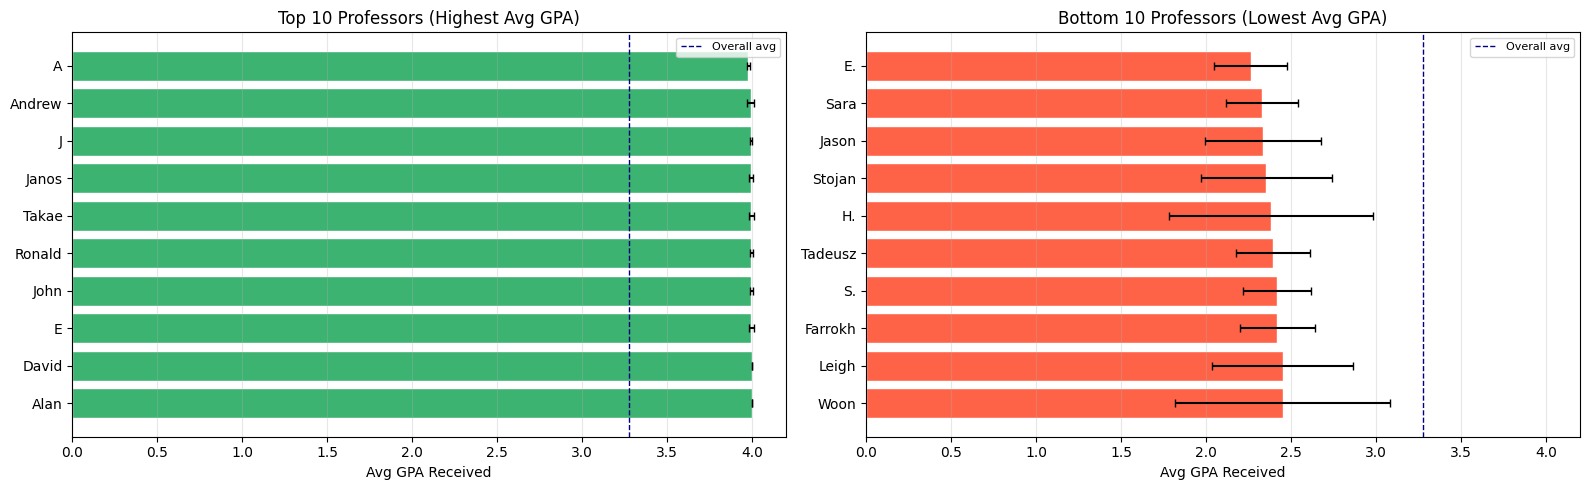

In [3]:
prof_stats = (
    df_clean
    .groupby('Instructor')
    .agg(
        avg_gpa    = ('GPA_Received', 'mean'),
        std_gpa    = ('GPA_Received', 'std'),
        n_courses  = ('GPA_Received', 'count'),
        avg_rec    = ('Pct_Rec_Prof', 'mean'),
        department = ('Department', lambda x: x.mode()[0])
    )
    .query('n_courses >= 5')
    .sort_values('avg_gpa', ascending=False)
)

print(f'Professors with >= 5 courses: {len(prof_stats):,}')

top10    = prof_stats.head(10)
bottom10 = prof_stats.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title, color in [
    (axes[0], top10,    'Top 10 Professors (Highest Avg GPA)',    'mediumseagreen'),
    (axes[1], bottom10, 'Bottom 10 Professors (Lowest Avg GPA)',  'tomato'),
]:
    names = [n.split()[-1] for n in data.index]  # last name only
    ax.barh(names, data['avg_gpa'], xerr=data['std_gpa'],
            color=color, edgecolor='white', capsize=3)
    ax.set_xlabel('Avg GPA Received')
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 4.2)
    ax.axvline(df_clean['GPA_Received'].mean(), color='navy',
               linestyle='--', linewidth=1, label='Overall avg')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/prof_top_bottom_gpa.png', dpi=150)
plt.show()

### 3.2 GPA Trend for a Specific Professor Over Time

Top 5 by course count: ['Walsh Kim C.', 'Anderson Michael G.', 'Chang Edmond Yi-Teh', 'Houskeeper Robert', 'Chen Pei-Chia']


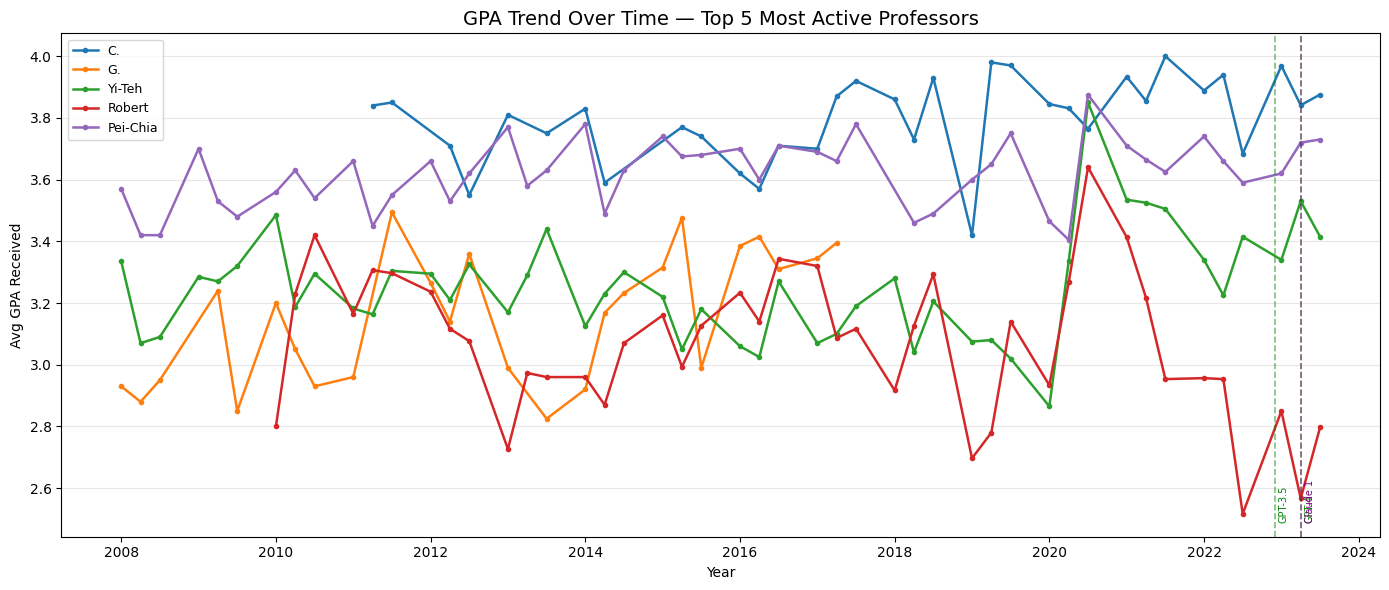

In [4]:
# Pick top 5 most-recorded professors for trend analysis
top5_profs = prof_stats.nlargest(5, 'n_courses').index.tolist()
print('Top 5 by course count:', top5_profs)

llm_events = [
    (2022 + 11/12, 'GPT-3.5', 'green'),
    (2023 + 3/12,  'GPT-4',   'green'),
    (2023 + 3/12,  'Claude 1','purple'),
]

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('tab10', 5)

for prof, color in zip(top5_profs, palette):
    sub = (
        df_clean[df_clean['Instructor'] == prof]
        .groupby('Quarter_Num')['GPA_Received']
        .mean()
        .sort_index()
    )
    ax.plot(sub.index, sub.values, label=prof.split()[-1],
            color=color, linewidth=1.8, marker='o', markersize=3)

for t, model, color in llm_events:
    ax.axvline(t, color=color, alpha=0.5, linewidth=1.2, linestyle='--')
    ax.text(t + 0.05, ax.get_ylim()[0] + 0.05, model,
            rotation=90, fontsize=7, color=color)

ax.set_title('GPA Trend Over Time — Top 5 Most Active Professors', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Avg GPA Received')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/prof_gpa_trend.png', dpi=150)
plt.show()

### 3.3 Recommendation Rate vs GPA — Scatter per Professor

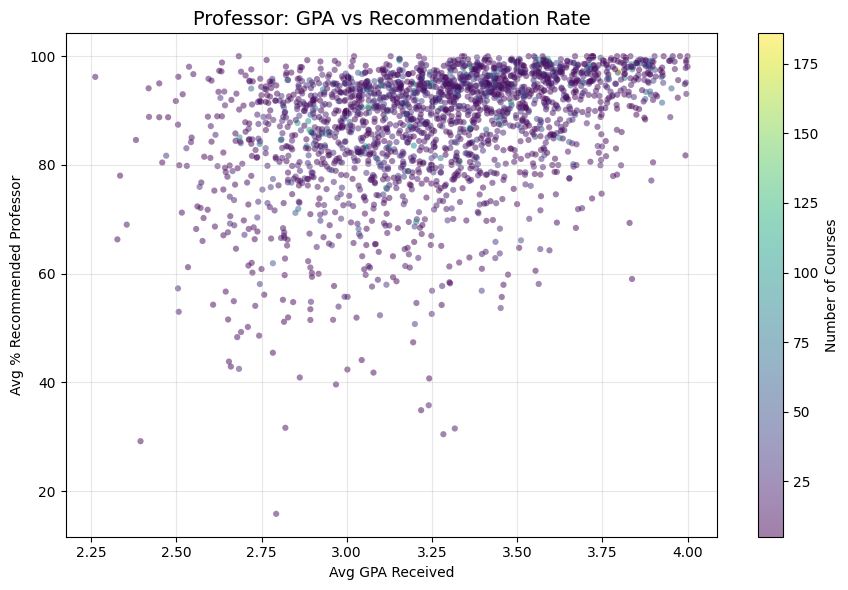

Pearson correlation (GPA vs Rec Rate): 0.364


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    prof_stats['avg_gpa'],
    prof_stats['avg_rec'],
    c=prof_stats['n_courses'], cmap='viridis',
    alpha=0.5, s=20, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Number of Courses')
ax.set_xlabel('Avg GPA Received')
ax.set_ylabel('Avg % Recommended Professor')
ax.set_title('Professor: GPA vs Recommendation Rate', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/prof_gpa_vs_rec.png', dpi=150)
plt.show()

corr = prof_stats['avg_gpa'].corr(prof_stats['avg_rec'])
print(f'Pearson correlation (GPA vs Rec Rate): {corr:.3f}')

## 4. RateMyProfessors Analysis

### 4.1 RMP Overview

In [6]:
print('RMP Professors columns:', rmp_profs.columns.tolist())
print(f'\nDepartments in RMP: {rmp_profs["department"].nunique()}')
rmp_profs[['firstName', 'lastName', 'department', 'avgRating',
           'avgDifficulty', 'numRatings', 'wouldTakeAgainPercent']].head()

RMP Professors columns: ['id', 'legacyId', 'firstName', 'lastName', 'department', 'avgRating', 'avgDifficulty', 'numRatings', 'wouldTakeAgainPercent', 'ratings_r1', 'ratings_r2', 'ratings_r3', 'ratings_r4', 'ratings_r5', 'ratings_total', 'attendance_yes', 'attendance_no', 'attendance_neither', 'credit_yes', 'credit_no', 'credit_neither', 'tag_1_name', 'tag_1_count', 'tag_2_name', 'tag_2_count', 'tag_3_name', 'tag_3_count', 'tag_4_name', 'tag_4_count', 'tag_5_name', 'tag_5_count']

Departments in RMP: 79


,firstName,lastName,department,avgRating,avgDifficulty,numRatings,wouldTakeAgainPercent
0,Edmond,Chang,History,3.9,3.3,282,66.1836
1,David,Quarfoot,Mathematics,3.6,3.6,180,63.6872
2,Jor-El,Briones,Computer Science,2.4,3.9,177,33.8983
3,Gaojin,He,Mathematics,1.5,4.6,127,10.2362
4,Cathleen,Moran,Management,2.5,3.7,76,26.3889


### 4.2 Rating & Difficulty Distribution

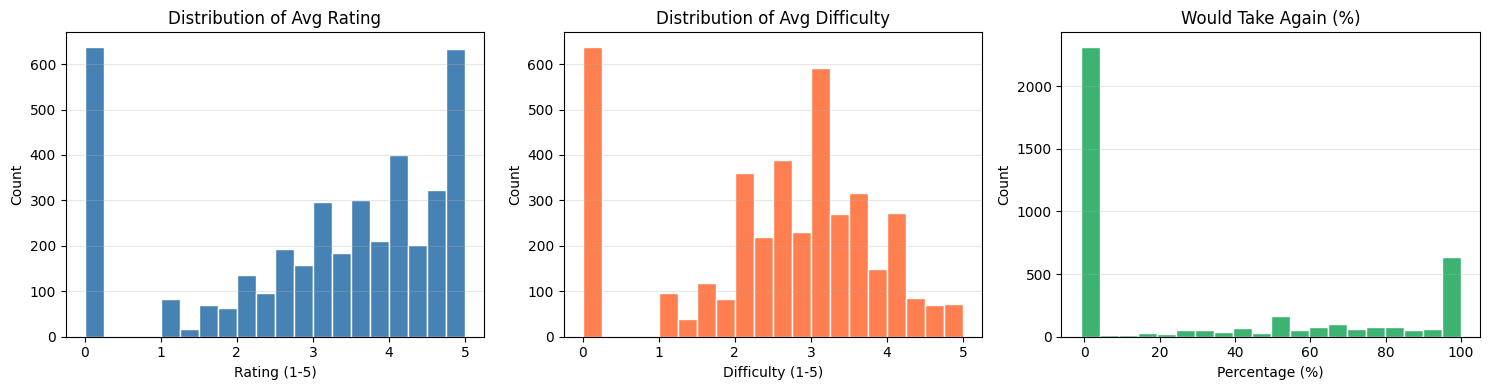

In [7]:
rmp = rmp_profs.copy()
rmp['avgRating']           = pd.to_numeric(rmp['avgRating'], errors='coerce')
rmp['avgDifficulty']       = pd.to_numeric(rmp['avgDifficulty'], errors='coerce')
rmp['wouldTakeAgainPercent'] = pd.to_numeric(rmp['wouldTakeAgainPercent'], errors='coerce')
rmp['numRatings']          = pd.to_numeric(rmp['numRatings'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rmp['avgRating'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Avg Rating')
axes[0].set_xlabel('Rating (1-5)')

axes[1].hist(rmp['avgDifficulty'].dropna(), bins=20, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Avg Difficulty')
axes[1].set_xlabel('Difficulty (1-5)')

axes[2].hist(rmp['wouldTakeAgainPercent'].dropna(), bins=20,
             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Would Take Again (%)')
axes[2].set_xlabel('Percentage (%)')

for ax in axes:
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/rmp_distributions.png', dpi=150)
plt.show()

### 4.3 Avg Rating by Department (Top 15 by count)

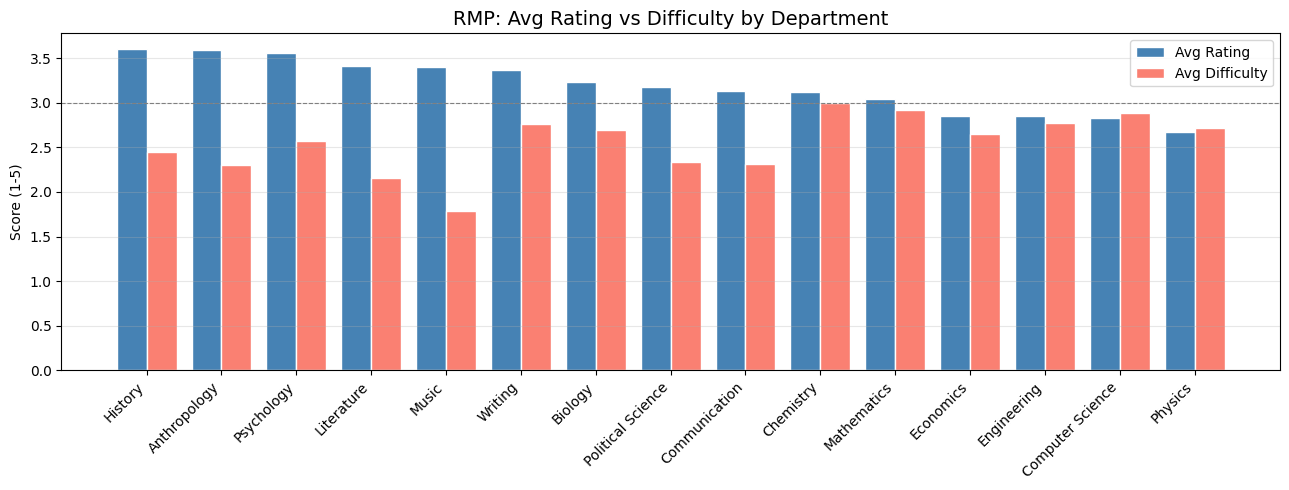

In [8]:
top_depts_rmp = rmp['department'].value_counts().head(15).index
rmp_top = rmp[rmp['department'].isin(top_depts_rmp)]

dept_rating = (
    rmp_top.groupby('department')[['avgRating', 'avgDifficulty']]
    .mean()
    .sort_values('avgRating', ascending=False)
)

x = range(len(dept_rating))
width = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i - width/2 for i in x], dept_rating['avgRating'],
       width=width, label='Avg Rating', color='steelblue', edgecolor='white')
ax.bar([i + width/2 for i in x], dept_rating['avgDifficulty'],
       width=width, label='Avg Difficulty', color='salmon', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(dept_rating.index, rotation=45, ha='right')
ax.set_title('RMP: Avg Rating vs Difficulty by Department', fontsize=14)
ax.set_ylabel('Score (1-5)')
ax.axhline(3, color='gray', linestyle='--', linewidth=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/rmp_dept_rating.png', dpi=150)
plt.show()

### 4.4 Rating vs Difficulty — Scatter

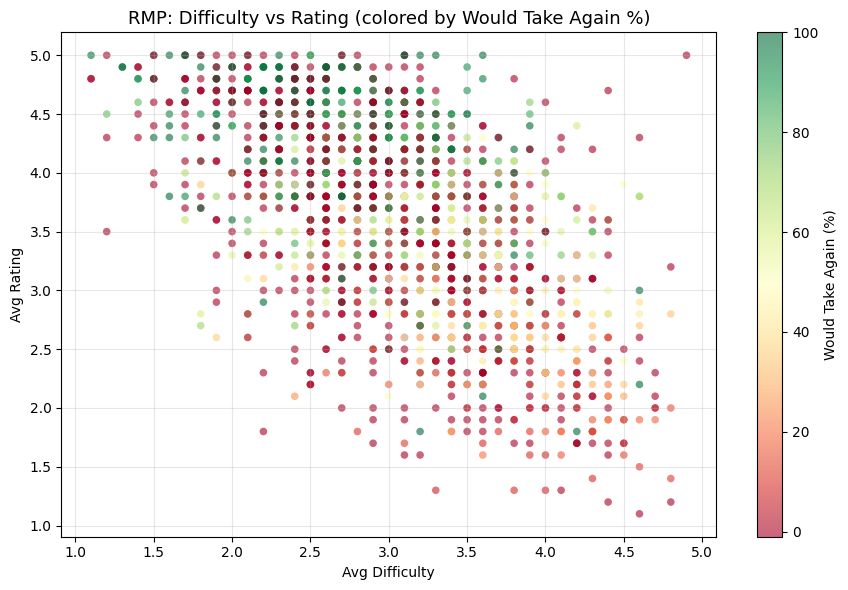

Pearson correlation (Difficulty vs Rating): -0.574


In [9]:
rmp_filtered = rmp[rmp['numRatings'] >= 10].dropna(
    subset=['avgRating', 'avgDifficulty', 'wouldTakeAgainPercent'])

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    rmp_filtered['avgDifficulty'],
    rmp_filtered['avgRating'],
    c=rmp_filtered['wouldTakeAgainPercent'],
    cmap='RdYlGn', alpha=0.6, s=30, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Would Take Again (%)')
ax.set_xlabel('Avg Difficulty')
ax.set_ylabel('Avg Rating')
ax.set_title('RMP: Difficulty vs Rating (colored by Would Take Again %)', fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/rmp_difficulty_vs_rating.png', dpi=150)
plt.show()

corr = rmp_filtered['avgDifficulty'].corr(rmp_filtered['avgRating'])
print(f'Pearson correlation (Difficulty vs Rating): {corr:.3f}')

## 5. Cross-Reference: RMP Rating vs CAPES GPA

In [10]:
# Build CAPES professor summary (last-name match)
capes_prof = (
    df_clean
    .groupby('Instructor')
    .agg(capes_gpa=('GPA_Received', 'mean'),
         capes_rec=('Pct_Rec_Prof', 'mean'))
    .reset_index()
)
# Extract last name for matching
capes_prof['last_name'] = capes_prof['Instructor'].str.split().str[0].str.rstrip(',')

# RMP: combine first+last name
rmp['last_name'] = rmp['lastName'].str.strip()
rmp_summary = rmp[['last_name', 'avgRating', 'avgDifficulty',
                    'wouldTakeAgainPercent', 'numRatings']].copy()
rmp_summary = rmp_summary[rmp_summary['numRatings'] >= 5]

# Merge on last name
merged = capes_prof.merge(rmp_summary, on='last_name', how='inner')
print(f'Matched professors: {len(merged)}')
merged[['Instructor', 'capes_gpa', 'avgRating', 'avgDifficulty']].head(10)

Matched professors: 4564


,Instructor,capes_gpa,avgRating,avgDifficulty
0,Aamari Eddie,3.007500,4.2,3.3
1,Abarbanel Henry Don Isaac,2.836667,2.4,3.3
2,Abrajano Marisa,3.246667,3.0,2.8
3,Abramson Ian S,3.070000,3.6,3.1
4,Ackerman Farrell,3.332258,3.6,2.5
5,Ackerman Susan,3.605000,3.6,2.5
6,Adamiak Patrick John,3.475000,4.2,2.5
7,Adida Claire,3.478333,4.4,2.0
8,Adler Amy,3.803636,4.8,2.6
9,Adler Amy,3.803636,3.1,3.4


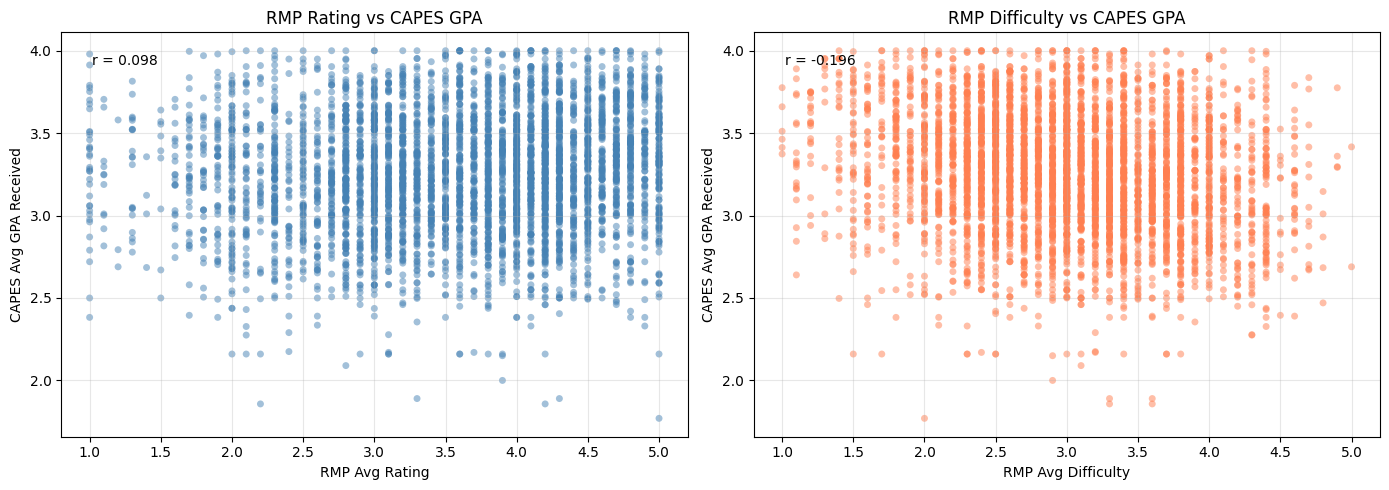

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMP Rating vs CAPES GPA
axes[0].scatter(merged['avgRating'], merged['capes_gpa'],
                alpha=0.5, color='steelblue', s=25, edgecolors='none')
axes[0].set_xlabel('RMP Avg Rating')
axes[0].set_ylabel('CAPES Avg GPA Received')
axes[0].set_title('RMP Rating vs CAPES GPA', fontsize=12)
axes[0].grid(alpha=0.3)
corr0 = merged['avgRating'].corr(merged['capes_gpa'])
axes[0].text(0.05, 0.92, f'r = {corr0:.3f}', transform=axes[0].transAxes, fontsize=10)

# RMP Difficulty vs CAPES GPA
axes[1].scatter(merged['avgDifficulty'], merged['capes_gpa'],
                alpha=0.5, color='coral', s=25, edgecolors='none')
axes[1].set_xlabel('RMP Avg Difficulty')
axes[1].set_ylabel('CAPES Avg GPA Received')
axes[1].set_title('RMP Difficulty vs CAPES GPA', fontsize=12)
axes[1].grid(alpha=0.3)
corr1 = merged['avgDifficulty'].corr(merged['capes_gpa'])
axes[1].text(0.05, 0.92, f'r = {corr1:.3f}', transform=axes[1].transAxes, fontsize=10)

plt.tight_layout()
plt.savefig('figures/rmp_vs_capes_gpa.png', dpi=150)
plt.show()